In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("students_ai_usage.csv")

In [7]:
df.head()

,age,education_level,study_hours_per_day,uses_ai,ai_tools_used,purpose_of_ai,grades_before_ai,grades_after_ai,daily_screen_time_hours
0,19,college,1.4,No,NaN,NaN,62,62,3
1,15,school,3.9,Yes,Copilot,Research,56,61,2
2,15,school,1.9,Yes,Copilot,Homework,75,88,5
3,15,school,2.8,No,NaN,NaN,55,55,3
4,19,college,2.7,No,NaN,NaN,59,59,3


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      100 non-null    int64  
 1   education_level          100 non-null    object 
 2   study_hours_per_day      100 non-null    float64
 3   uses_ai                  100 non-null    object 
 4   ai_tools_used            40 non-null     object 
 5   purpose_of_ai            40 non-null     object 
 6   grades_before_ai         100 non-null    int64  
 7   grades_after_ai          100 non-null    int64  
 8   daily_screen_time_hours  100 non-null    int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 7.2+ KB


In [11]:
df.describe()

,age,study_hours_per_day,grades_before_ai,grades_after_ai,daily_screen_time_hours
count,100.000000,100.000000,100.00000,100.000000,100.000000
mean,16.490000,2.987000,64.77000,68.700000,4.340000
std,1.702612,1.145713,6.16909,8.140806,1.793479
min,14.000000,1.000000,55.00000,55.000000,2.000000
25%,15.000000,1.975000,59.00000,61.000000,3.000000
50%,16.000000,2.800000,63.00000,69.000000,4.000000
75%,18.000000,4.025000,70.00000,74.000000,6.000000
max,19.000000,5.000000,75.00000,89.000000,7.000000


In [14]:
df.shape

(100, 9)

In [18]:
df.isnull().sum()

age                         0
education_level             0
study_hours_per_day         0
uses_ai                     0
ai_tools_used              60
purpose_of_ai              60
grades_before_ai            0
grades_after_ai             0
daily_screen_time_hours     0
dtype: int64

In [24]:
df['ai_tools_used'].value_counts()

ai_tools_used
Copilot    14
Gemini     13
ChatGPT    13
Name: count, dtype: int64

In [26]:
df['uses_ai'].value_counts()

uses_ai
No     60
Yes    40
Name: count, dtype: int64

In [30]:
df.duplicated().sum()

0

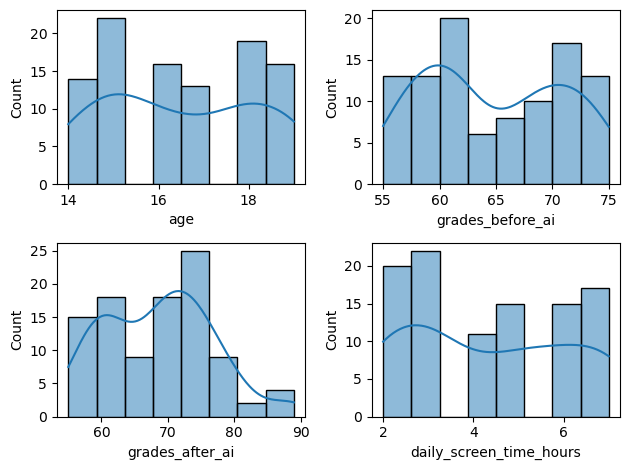

In [32]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde = True)

plotting('age',1)
plotting('grades_before_ai',2)
plotting('grades_after_ai',3)
plotting('daily_screen_time_hours',4)


plt.tight_layout()

In [34]:
df_ai_usage = df[df['uses_ai'] == 'Yes']

In [38]:
df_ai_usage['education_level'].value_counts()

education_level
school     20
college    20
Name: count, dtype: int64

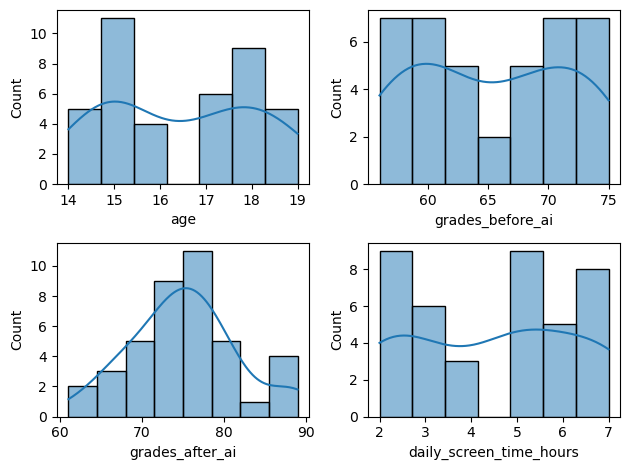

In [40]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df_ai_usage[var],kde = True)

plotting('age',1)
plotting('grades_before_ai',2)
plotting('grades_after_ai',3)
plotting('daily_screen_time_hours',4)


plt.tight_layout()

<Axes: xlabel='age', ylabel='count'>

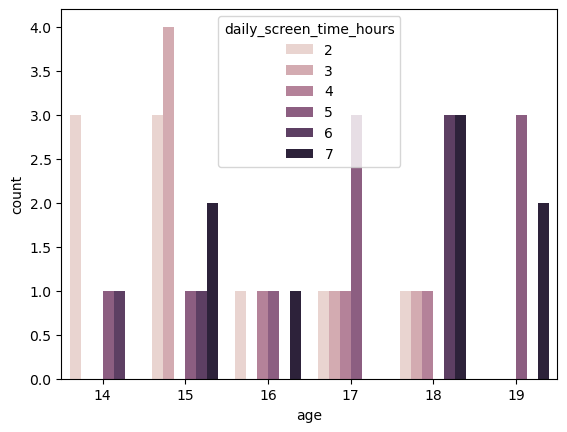

In [44]:
sns.countplot(x = df_ai_usage['age'], hue = df_ai_usage['daily_screen_time_hours'])

<Axes: xlabel='grades_before_ai', ylabel='count'>

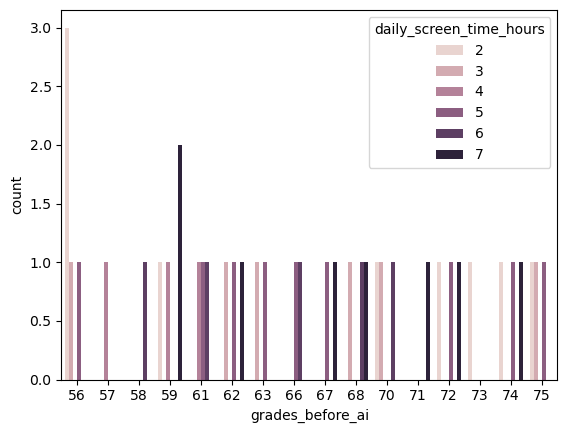

In [46]:
sns.countplot(x = df_ai_usage['grades_before_ai'], hue = df_ai_usage['daily_screen_time_hours'])

<Axes: xlabel='daily_screen_time_hours', ylabel='grades_before_ai'>

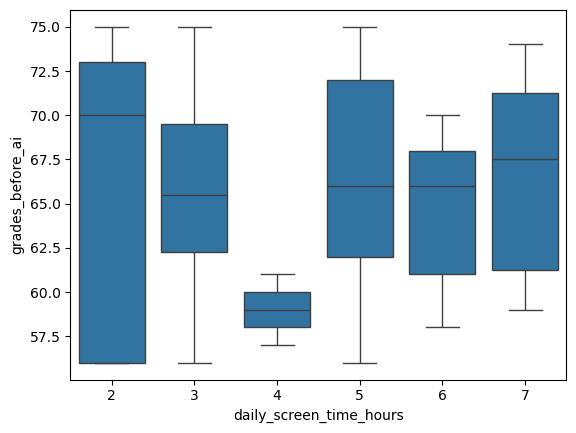

In [52]:
sns.boxplot(x = 'daily_screen_time_hours', y = 'grades_before_ai',data = df_ai_usage)

<Axes: xlabel='daily_screen_time_hours', ylabel='grades_after_ai'>

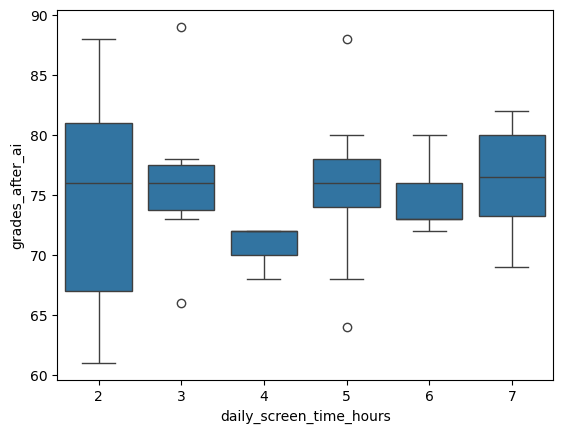

In [54]:
sns.boxplot(x = 'daily_screen_time_hours', y = 'grades_after_ai',data = df_ai_usage)

<Axes: >

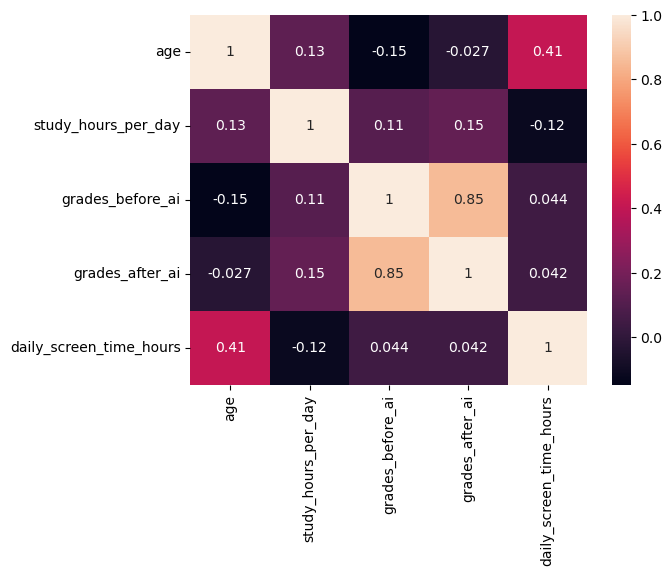

In [56]:
sns.heatmap(df_ai_usage.corr(numeric_only=True), annot=True)

In [58]:
df_encode = pd.get_dummies(df_ai_usage)

In [60]:
df_encode

,age,study_hours_per_day,grades_before_ai,grades_after_ai,daily_screen_time_hours,education_level_college,education_level_school,uses_ai_Yes,ai_tools_used_ChatGPT,ai_tools_used_Copilot,ai_tools_used_Gemini,purpose_of_ai_Coding,purpose_of_ai_Homework,purpose_of_ai_Research
1,15,3.9,56,61,2,False,True,True,False,True,False,False,False,True
2,15,1.9,75,88,5,False,True,True,False,True,False,False,True,False
6,16,3.4,72,78,5,False,True,True,False,True,False,False,False,True
8,19,1.3,62,68,5,True,False,True,False,False,True,False,True,False
11,18,3.5,67,76,7,True,False,True,True,False,False,False,False,True
17,18,2.6,70,76,2,True,False,True,True,False,False,True,False,False
18,14,1.6,74,80,5,False,True,True,False,True,False,False,False,True
20,18,4.4,58,73,6,True,False,True,False,True,False,True,False,False
22,17,1.6,63,76,3,True,False,True,False,True,False,True,False,False
27,15,4.5,70,76,6,False,True,True,True,False,False,True,False,False


In [64]:
df_encode = df_encode.astype(int)

In [66]:
df_encode.head()

,age,study_hours_per_day,grades_before_ai,grades_after_ai,daily_screen_time_hours,education_level_college,education_level_school,uses_ai_Yes,ai_tools_used_ChatGPT,ai_tools_used_Copilot,ai_tools_used_Gemini,purpose_of_ai_Coding,purpose_of_ai_Homework,purpose_of_ai_Research
1,15,3,56,61,2,0,1,1,0,1,0,0,0,1
2,15,1,75,88,5,0,1,1,0,1,0,0,1,0
6,16,3,72,78,5,0,1,1,0,1,0,0,0,1
8,19,1,62,68,5,1,0,1,0,0,1,0,1,0
11,18,3,67,76,7,1,0,1,1,0,0,0,0,1


In [68]:
from sklearn.preprocessing import StandardScaler
numerical_cols = ['age', 'study_hours_per_day', 'grades_before_ai', 'grades_after_ai']
scaler = StandardScaler()
df_encode[numerical_cols] = scaler.fit_transform(df_encode[numerical_cols])
df_encode.head()

,age,study_hours_per_day,grades_before_ai,grades_after_ai,daily_screen_time_hours,education_level_college,education_level_school,uses_ai_Yes,ai_tools_used_ChatGPT,ai_tools_used_Copilot,ai_tools_used_Gemini,purpose_of_ai_Coding,purpose_of_ai_Homework,purpose_of_ai_Research
1,-0.874781,0.648622,-1.455090,-2.181381,2,0,1,1,0,1,0,0,0,1
2,-0.874781,-1.140680,1.509704,1.980971,5,0,1,1,0,1,0,0,1,0
6,-0.271484,0.648622,1.041579,0.439359,5,0,1,1,0,1,0,0,0,1
8,1.538407,-1.140680,-0.518839,-1.102252,5,1,0,1,0,0,1,0,1,0
11,0.935110,0.648622,0.261370,0.131037,7,1,0,1,1,0,0,0,0,1
